In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
df = sns.load_dataset("titanic")

In [2]:
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape) # satır ve sütun sayısı
    print("##################### Types #####################")
    print(dataframe.dtypes) # veri tipleri
    print("##################### Head #####################")
    print(dataframe.head(head)) # ilk 5 satır
    print("##################### Tail #####################")
    print(dataframe.tail(head)) # son 5 satır
    print("##################### NA #####################")
    print(dataframe.isnull().sum()) # NA değerlerinin sayısı
    print("##################### Quantiles #####################")
    print(dataframe.describe([0, 0.05, 0.50, 0.95, 0.99, 1]).T) # istatistiksel özet


In [3]:
check_df(df)

##################### Shape #####################
(891, 15)
##################### Types #####################
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
##################### Head #####################
   survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male  22.0      1      0   7.2500        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female  38.0      1      0  71.2833        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female  26.0      0      0   7.9250        S  Third  woman       False  NaN  

In [4]:
df = sns.load_dataset("flights")
check_df(df)

##################### Shape #####################
(144, 3)
##################### Types #####################
year             int64
month         category
passengers       int64
dtype: object
##################### Head #####################
   year month  passengers
0  1949   Jan         112
1  1949   Feb         118
2  1949   Mar         132
3  1949   Apr         129
4  1949   May         121
##################### Tail #####################
     year month  passengers
139  1960   Aug         606
140  1960   Sep         508
141  1960   Oct         461
142  1960   Nov         390
143  1960   Dec         432
##################### NA #####################
year          0
month         0
passengers    0
dtype: int64
##################### Quantiles #####################
            count         mean         std     min      0%      5%     50%      95%      99%    100%     max
year        144.0  1954.500000    3.464102  1949.0  1949.0  1949.0  1954.5  1960.00  1960.00  1960.0  1960.0
passen

## Kategorik Değişken Analizi (Analysis of Categorical Variables)


In [6]:
df = sns.load_dataset("titanic")
df["embarked"].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [7]:
df["sex"].unique() # benzersiz değerler

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [9]:
df["class"].nunique() # benzersiz değer sayısı

3

In [11]:
# Kategorik değişkenleri seçmek için, sütunların veri tipleri "category", "object" (yani string) veya "bool" olmalı.
cat_cols = [col for col in df.columns if str(df[col].dtypes) in ["category", "object", "bool"]]

# cat_cols, DataFrame'deki kategorik değişkenlerin isimlerini içeren bir listedir.
cat_cols

['class', 'adult_male', 'deck', 'alone']

In [12]:
# Kategorik gibi davranan fakat aslında sayısal (int veya float tipinde) olan değişkenleri bulmak için,
# bu değişkenlerin benzersiz değer sayısı 10'dan az olmalıdır.
# Yani, df'deki sütunlardan veri tipi int veya float olup, eşsiz değer sayısı 10'dan az olanlar seçiliyor.
num_but_cat = [col for col in df.columns if df[col].nunique() < 10 and df[col].dtypes in ["int", "float"]]
num_but_cat  # Sayısal olduğu halde, kategorik olarak değerlendirebileceğimiz değişkenlerin isimleri burada listelenir.

['survived', 'pclass', 'sibsp', 'parch']

In [13]:
# Kategorik olup, yüksek kardinaliteye (yani çok fazla benzersiz değere) sahip değişkenleri bulmak için:
# - Sütunların veri tipi "category" ya da "object" olacak (yani kategorik olacak),
# - Ancak benzersiz değer (unique) sayısı 20'den fazla olacak.
# Bu tür değişkenler genellikle "categorical but cardinal" (çok seviyeli kategorik) olarak adlandırılır ve
# modelleme süreçlerinde özel ilgi gerektirirler.
cat_but_car = [col for col in df.columns if df[col].nunique() > 20 and str(df[col].dtypes) in ["category", "object"]]
cat_but_car  # Yüksek kardinaliteye sahip kategorik değişkenlerin isimleri burada listelenir.

[]

In [14]:
cat_cols = cat_cols + num_but_cat
cat_cols

['class',
 'adult_male',
 'deck',
 'alone',
 'survived',
 'pclass',
 'sibsp',
 'parch']

In [15]:
cat_cols = [col for col in cat_cols if col not in cat_but_car] # Çok seviyeli kategorik değişkenleri kaldır

In [16]:
cat_cols

['class',
 'adult_male',
 'deck',
 'alone',
 'survived',
 'pclass',
 'sibsp',
 'parch']

In [17]:
df[cat_cols].nunique()

class         3
adult_male    2
deck          7
alone         2
survived      2
pclass        3
sibsp         7
parch         7
dtype: int64

In [18]:
[col for col in df.columns if col not in cat_cols]

['sex', 'age', 'fare', 'embarked', 'who', 'embark_town', 'alive']

In [21]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

cat_summary(df, "sex")

        sex      Ratio
sex                   
male    577  64.758698
female  314  35.241302
##########################################


In [22]:
for col in cat_cols:
    cat_summary(df,col)

        class      Ratio
class                   
Third     491  55.106622
First     216  24.242424
Second    184  20.650954
##########################################
            adult_male     Ratio
adult_male                      
True               537  60.26936
False              354  39.73064
##########################################
      deck     Ratio
deck                
C       59  6.621773
B       47  5.274972
D       33  3.703704
E       32  3.591470
A       15  1.683502
F       13  1.459035
G        4  0.448934
##########################################
       alone     Ratio
alone                 
True     537  60.26936
False    354  39.73064
##########################################
          survived      Ratio
survived                     
0              549  61.616162
1              342  38.383838
##########################################
        pclass      Ratio
pclass                   
3          491  55.106622
1          216  24.242424
2          184  20.6509

        sex      Ratio
sex                   
male    577  64.758698
female  314  35.241302
##########################################


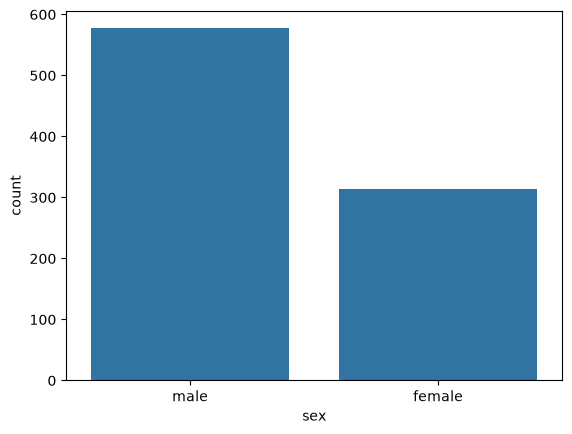

In [23]:
def cat_summary(dataframe, col_name, plot=False):
    """
    Belirtilen dataframe ve sütun ismi için, sütundaki kategorik değerlerin 
    hem frekans (adet) hem de oran (yüzde) dağılımını gösteren bir özet tablo oluşturur ve yazdırır.
    
    Eğer plot=True olarak verilirse, ilgili sütunun kategorik dağılımını görselleştiren bir countplot grafiği de çizer.

    Parametreler:
      dataframe: Pandas DataFrame, analiz yapılacak veri seti.
      col_name: string, özetlenmesi istenen kategorik sütunun adı.
      plot: bool, varsayılan False. True verilirse sütunun dağılımını görselleştirir.

    Fonksiyonun İşleyişi:
      1. value_counts() ile kategori adetlerini, bunların toplam içindeki yüzdesini hesaplar ve bir tablo olarak yazdırır.
      2. plot=True ise seaborn.countplot ile ilgili değişkenin dağılım grafiğini çizer.
    """
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

    if plot:
        sns.countplot(x=dataframe[col_name], data=dataframe)
        plt.show(block=True)

cat_summary(df, "sex", plot=True)


        class      Ratio
class                   
Third     491  55.106622
First     216  24.242424
Second    184  20.650954
##########################################


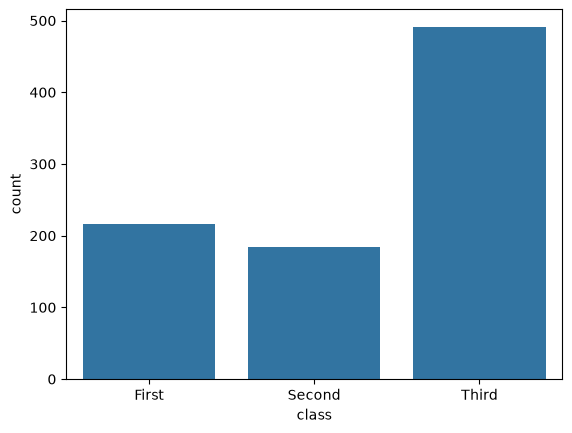

sdfsdfsdfsdfsdfsd
      deck     Ratio
deck                
C       59  6.621773
B       47  5.274972
D       33  3.703704
E       32  3.591470
A       15  1.683502
F       13  1.459035
G        4  0.448934
##########################################


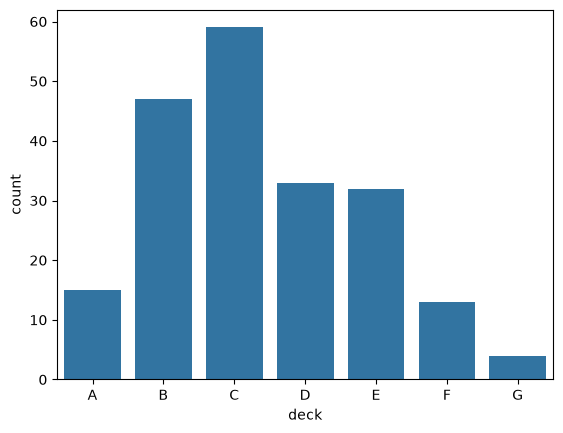

sdfsdfsdfsdfsdfsd
          survived      Ratio
survived                     
0              549  61.616162
1              342  38.383838
##########################################


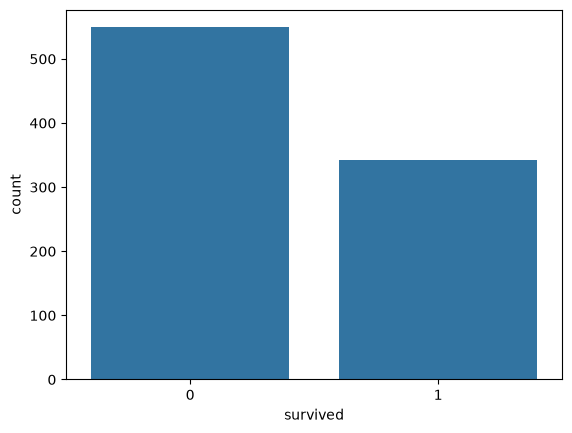

        pclass      Ratio
pclass                   
3          491  55.106622
1          216  24.242424
2          184  20.650954
##########################################


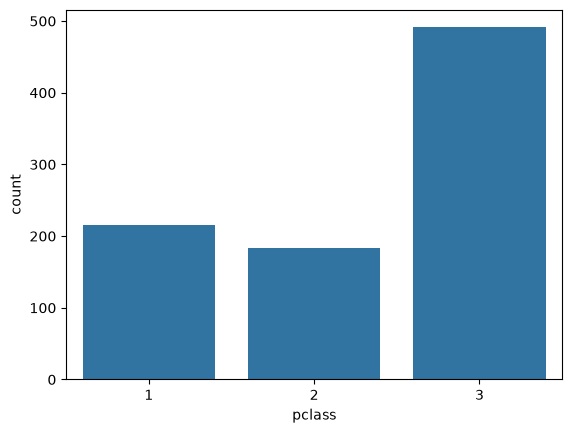

       sibsp      Ratio
sibsp                  
0        608  68.237935
1        209  23.456790
2         28   3.142536
4         18   2.020202
3         16   1.795735
8          7   0.785634
5          5   0.561167
##########################################


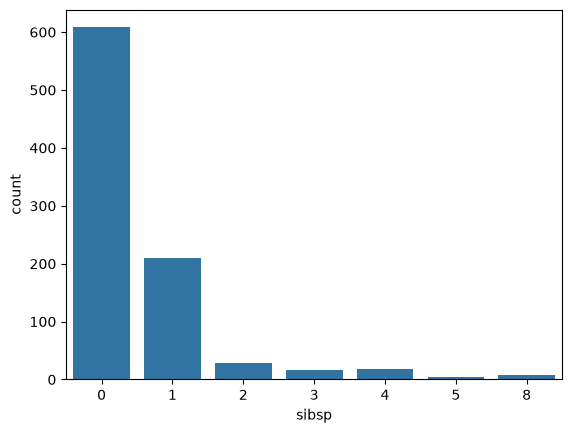

       parch      Ratio
parch                  
0        678  76.094276
1        118  13.243547
2         80   8.978676
5          5   0.561167
3          5   0.561167
4          4   0.448934
6          1   0.112233
##########################################


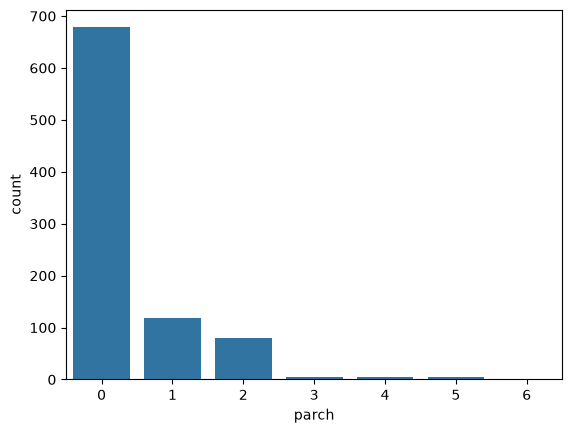

In [24]:
for col in cat_cols:
    if df[col].dtypes == "bool":
        print("sdfsdfsdfsdfsdfsd")
    else:
        cat_summary(df, col, plot=True)



In [26]:
df["adult_male"].astype(int) # bool değişkenleri int'e çevirir


0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: adult_male, Length: 891, dtype: int64

        class      Ratio
class                   
Third     491  55.106622
First     216  24.242424
Second    184  20.650954
##########################################


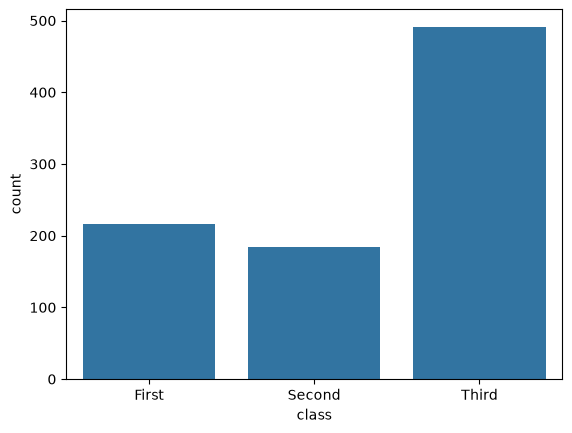

            adult_male     Ratio
adult_male                      
1                  537  60.26936
0                  354  39.73064
##########################################


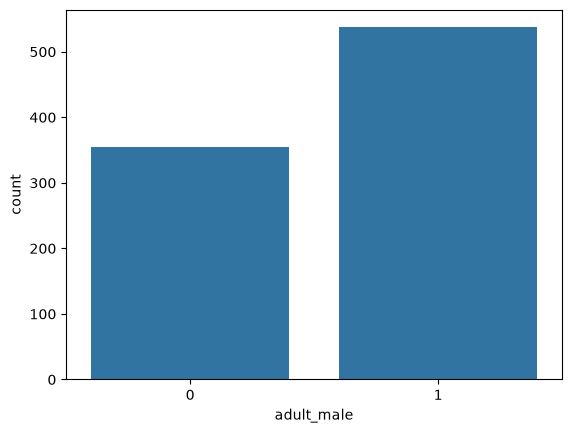

      deck     Ratio
deck                
C       59  6.621773
B       47  5.274972
D       33  3.703704
E       32  3.591470
A       15  1.683502
F       13  1.459035
G        4  0.448934
##########################################


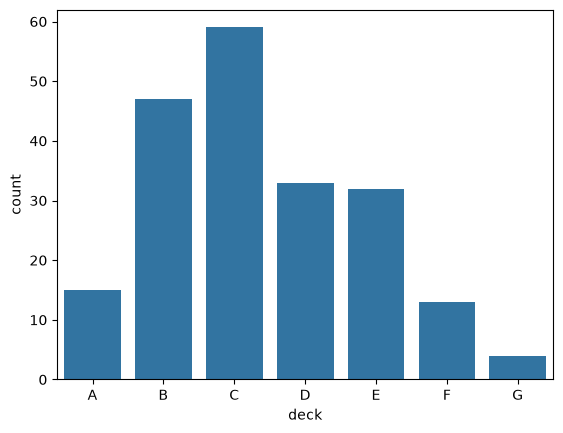

       alone     Ratio
alone                 
1        537  60.26936
0        354  39.73064
##########################################


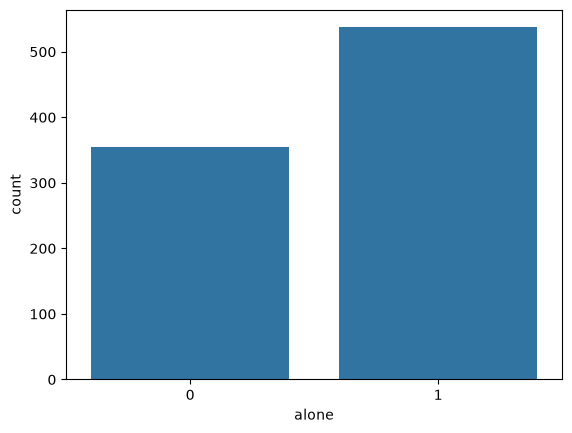

          survived      Ratio
survived                     
0              549  61.616162
1              342  38.383838
##########################################


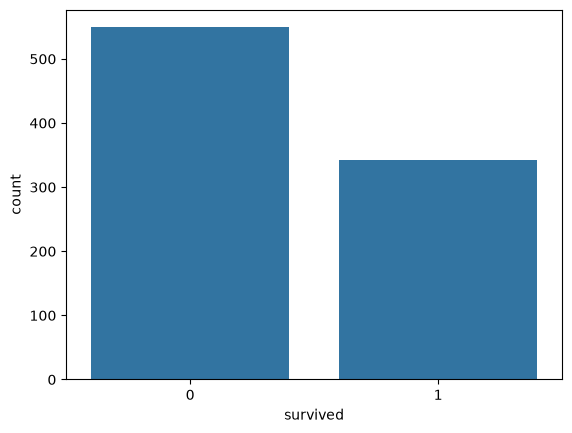

        pclass      Ratio
pclass                   
3          491  55.106622
1          216  24.242424
2          184  20.650954
##########################################


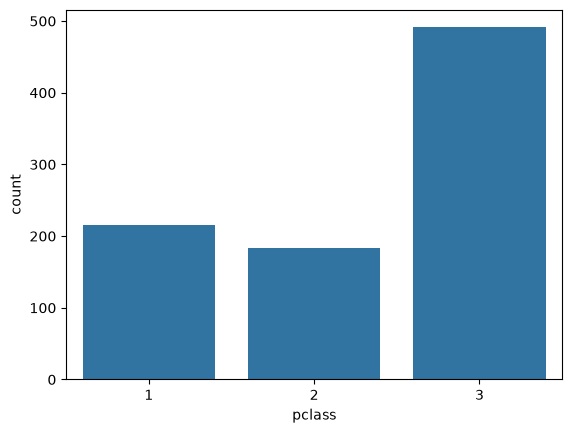

       sibsp      Ratio
sibsp                  
0        608  68.237935
1        209  23.456790
2         28   3.142536
4         18   2.020202
3         16   1.795735
8          7   0.785634
5          5   0.561167
##########################################


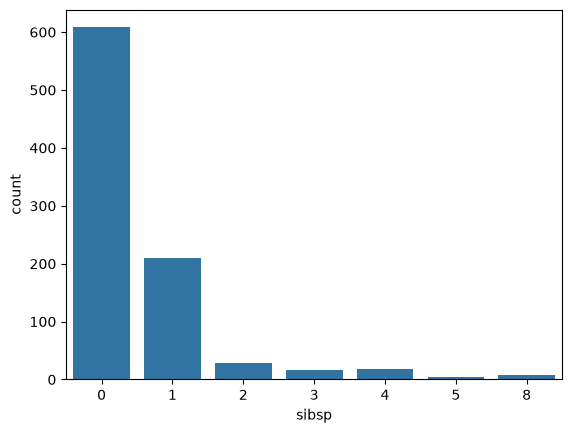

       parch      Ratio
parch                  
0        678  76.094276
1        118  13.243547
2         80   8.978676
5          5   0.561167
3          5   0.561167
4          4   0.448934
6          1   0.112233
##########################################


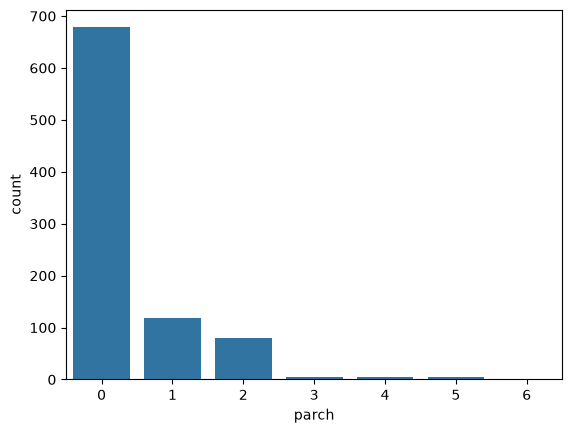

In [27]:
for col in cat_cols:
    if df[col].dtypes == "bool":
        df[col] = df[col].astype(int)
        cat_summary(df, col, plot=True)

    else:
        cat_summary(df, col, plot=True)

            adult_male     Ratio
adult_male                      
1                  537  60.26936
0                  354  39.73064
##########################################


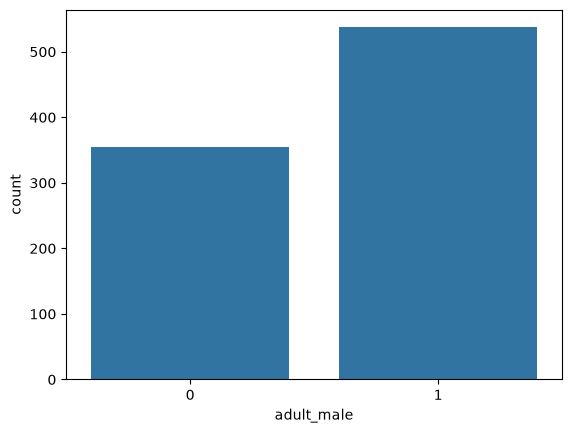

In [28]:

def cat_summary(dataframe, col_name, plot=False):

    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int)

        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("##########################################")

        if plot:
            sns.countplot(x=dataframe[col_name], data=dataframe)
            plt.show(block=True)
    else:
        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("##########################################")

        if plot:
            sns.countplot(x=dataframe[col_name], data=dataframe)
            plt.show(block=True)

cat_summary(df, "adult_male", plot=True)

## Sayısal Değişken Analizi

In [30]:
df[["age", "fare"]].describe().T

,count,mean,std,min,25%,50%,75%,max
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [31]:
num_cols = [col for col in df.columns if df[col].dtypes in ["int","float"]]
num_cols

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone']

In [32]:
num_cols = [col for col in num_cols if col not in cat_cols]
num_cols

['age', 'fare']

In [33]:
def num_summary(dataframe, numerical_col):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

num_summary(df, "age")


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
95%       56.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64


In [34]:
for col in num_cols:
    num_summary(df, col)


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
95%       56.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64
count    891.000000
mean      32.204208
std       49.693429
min        0.000000
5%         7.225000
10%        7.550000
20%        7.854200
30%        8.050000
40%       10.500000
50%       14.454200
60%       21.679200
70%       27.000000
80%       39.687500
90%       77.958300
95%      112.079150
99%      249.006220
max      512.329200
Name: fare, dtype: float64


count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
95%       56.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64


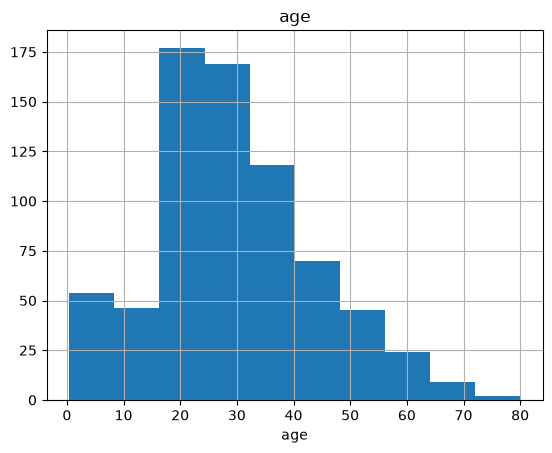

In [36]:
def num_summary(dataframe, numerical_col, plot=False):
    """
    Verilen dataframe'de, belirtilen sayısal değişkenin temel istatistiksel özetini ve yüzdelik değerlerini gösterir. 
    plot=True olarak ayarlanırsa, ilgili değişkenin histogramını çizer.

    Parametreler
    ------------
    dataframe : pandas.DataFrame
        Analizi yapılacak veri çerçevesi.
    numerical_col : str
        Temel istatistiklerin hesaplanacağı sayısal değişken ismi.
    plot : bool, opsiyonel
        Eğer True verilirse değişkenin histogramı çizilir, varsayılan olarak False.

    Kullanım
    --------
    num_summary(df, "age", plot=True)
    """
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    summary = dataframe[numerical_col].describe(quantiles).T
    print(summary)

    if plot:
        dataframe[numerical_col].hist()
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show(block=True)


num_summary(df, "age", plot=True)

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
95%       56.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64


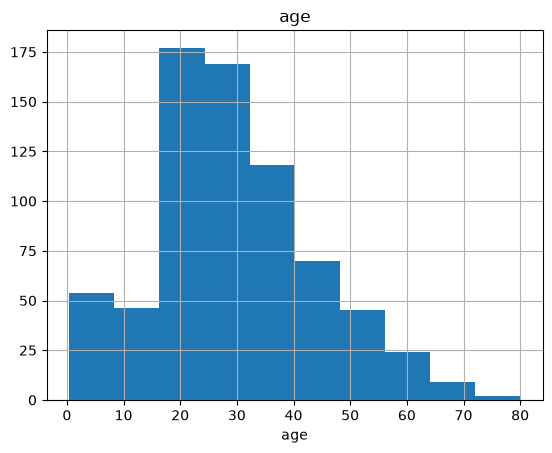

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
5%         7.225000
10%        7.550000
20%        7.854200
30%        8.050000
40%       10.500000
50%       14.454200
60%       21.679200
70%       27.000000
80%       39.687500
90%       77.958300
95%      112.079150
99%      249.006220
max      512.329200
Name: fare, dtype: float64


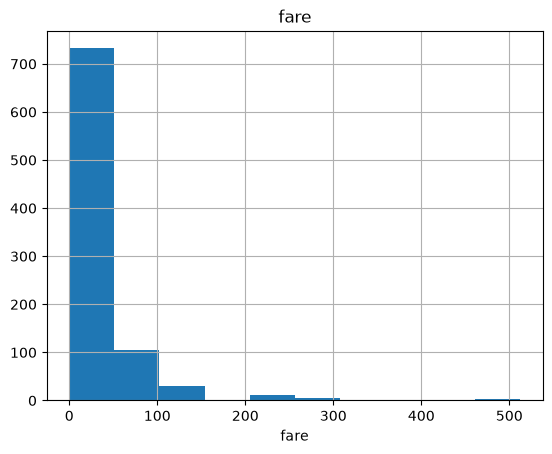

In [37]:
for col in num_cols:
    num_summary(df, col, plot=True)


## Değişkenlerin Yakalanması ve İşlemlerin Genelleştirilmesi


In [38]:
def grab_col_names(dataframe, cat_th=10,  car_th=20):
    """
    Bu fonksiyon, verilen bir veri setindeki değişkenleri kategorik, nümerik ve kategorik olup kardinal olanlar (çok fazla benzersiz değere sahip olanlar) olarak gruplar ve isimlerini döndürür.

    Parametreler
    -------------
    dataframe : pandas.DataFrame
        Sütun isimleri incelenecek olan veri çerçevesi.
    cat_th : int veya float
        Sayısal olup aslında kategorik olarak değerlendirilecek değişkenler için sınıf eşik değeri.
    car_th : int veya float
        Kategorik olup çok fazla benzersiz gözleme sahip değişkenler için kardinalite (benzersizlik) eşik değeri.

    Dönüş Değerleri
    ----------------
    cat_cols : list
        Kategorik değişkenlerin isimlerini içeren liste.
    num_cols : list
        Nümerik değişkenlerin isimlerini içeren liste.
    cat_but_car : list
        Kategorik görünümlü, kardinal (çok farklı değere sahip) değişkenlerin isimlerini içeren liste.

    Notlar
    ---------
    cat_cols + num_cols + cat_but_car = toplam değişken sayısıdır.
    num_but_cat, cat_cols listesi içinde yer almaktadır.


    """
    # cat_cols, cat_but_car
    cat_cols = [col for col in dataframe.columns if str(dataframe[col].dtypes) in ["category", "object", "bool"]]

    num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < 10 and dataframe[col].dtypes in ["int", "float"]]

    cat_but_car = [col for col in dataframe.columns if
                   dataframe[col].nunique() > 20 and str(dataframe[col].dtypes) in ["category", "object"]]

    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in cat_but_car]

    num_cols = [col for col in dataframe.columns if dataframe[col].dtypes in ["int", "float"]]
    num_cols = [col for col in num_cols if col not in cat_cols]

    print(f"Observations: {dataframe.shape[0]}")
    print(f"Variables: {dataframe.shape[1]}")
    print(f'cat_cols: {len(cat_cols)}')
    print(f'num_cols: {len(num_cols)}')
    print(f'cat_but_car: {len(cat_but_car)}')
    print(f'num_but_cat: {len(num_but_cat)}')

    return cat_cols, num_cols, cat_but_car


cat_cols, num_cols, cat_but_car = grab_col_names(df)


Observations: 891
Variables: 15
cat_cols: 8
num_cols: 2
cat_but_car: 0
num_but_cat: 6


In [39]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

cat_summary(df, "sex")

        sex      Ratio
sex                   
male    577  64.758698
female  314  35.241302
##########################################


In [40]:
for col in cat_cols:
    cat_summary(df, col)

        class      Ratio
class                   
Third     491  55.106622
First     216  24.242424
Second    184  20.650954
##########################################
      deck     Ratio
deck                
C       59  6.621773
B       47  5.274972
D       33  3.703704
E       32  3.591470
A       15  1.683502
F       13  1.459035
G        4  0.448934
##########################################
          survived      Ratio
survived                     
0              549  61.616162
1              342  38.383838
##########################################
        pclass      Ratio
pclass                   
3          491  55.106622
1          216  24.242424
2          184  20.650954
##########################################
       sibsp      Ratio
sibsp                  
0        608  68.237935
1        209  23.456790
2         28   3.142536
4         18   2.020202
3         16   1.795735
8          7   0.785634
5          5   0.561167
##########################################
     

Observations: 891
Variables: 15
cat_cols: 8
num_cols: 2
cat_but_car: 0
num_but_cat: 6
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
5%         4.000000
10%       14.000000
20%       19.000000
30%       22.000000
40%       25.000000
50%       28.000000
60%       31.800000
70%       36.000000
80%       41.000000
90%       50.000000
95%       56.000000
99%       65.870000
max       80.000000
Name: age, dtype: float64


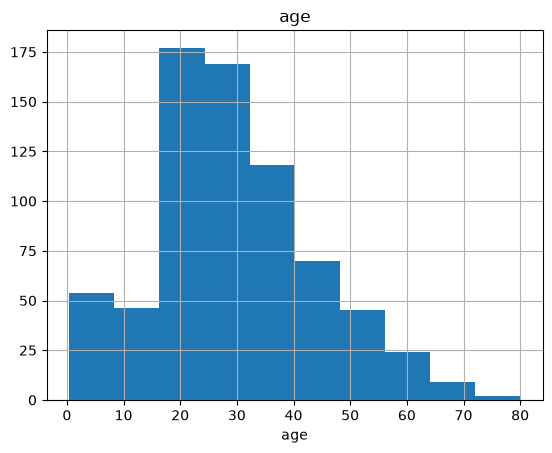

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
5%         7.225000
10%        7.550000
20%        7.854200
30%        8.050000
40%       10.500000
50%       14.454200
60%       21.679200
70%       27.000000
80%       39.687500
90%       77.958300
95%      112.079150
99%      249.006220
max      512.329200
Name: fare, dtype: float64


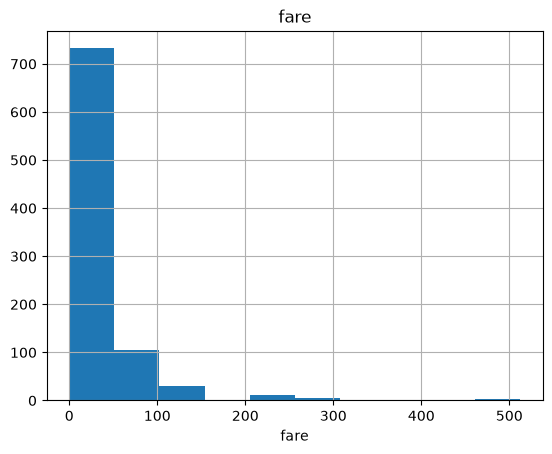

In [42]:
for col in df.columns:
    if df[col].dtypes == "bool":
        df[col] = df[col].astype(int)
       
cat_cols, num_cols, cat_but_car = grab_col_names(df)

def cat_summary(dataframe, col_name, plot=False):
    if dataframe[col_name].dtypes == "bool":
        dataframe[col_name] = dataframe[col_name].astype(int)

        print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                            "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
        print("##########################################")

for col in num_cols:
    cat_summary(df, col,plot=True)


for col in num_cols:
    num_summary(df, col, plot=True)


Hedef Değişken Analizi (Analysis of Target Variable)

In [43]:
df["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [45]:
def cat_summary(dataframe, col_name):
    print(pd.DataFrame({col_name: dataframe[col_name].value_counts(),
                        "Ratio": 100 * dataframe[col_name].value_counts() / len(dataframe)}))
    print("##########################################")

cat_summary(df, "survived")


          survived      Ratio
survived                     
0              549  61.616162
1              342  38.383838
##########################################


In [46]:
df.groupby("sex")["survived"].mean()


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

In [47]:
def target_summary_with_cat(dataframe, target, categorical_col):
    """
    Belirli bir kategorik değişkenin (categorical_col) kategorilerine göre hedef değişkenin (target)
    ortalamasını hesaplar ve ekrana bastırır.

    Parameters
    ----------
    dataframe: pd.DataFrame
        İşlem yapılacak veri seti.
    target: str
        Hedef değişkenin ismi.
    categorical_col: str
        Kategorik değişkenin ismi.

    Returns
    -------
    None, sadece çıktıyı ekrana basar.
    """
    target_means = dataframe.groupby(categorical_col)[target].mean()
    print(pd.DataFrame({"TARGET_MEAN": target_means}), end="\n\n\n")
    print(f"Yukarıdaki tablo, '{categorical_col}' değişkeninin her bir kategorisi için '{target}' değişkeninin ortalamasını gösterir. Bu analiz, örneğin yolcu sınıfına (pclass) göre hayatta kalma oranlarının nasıl değiştiğini anlamamıza yardımcı olur.")

target_summary_with_cat(df, "survived", "pclass")

        TARGET_MEAN
pclass             
1          0.629630
2          0.472826
3          0.242363




In [48]:
for col in cat_cols:
    target_summary_with_cat(df, "survived", col)

        TARGET_MEAN
class              
First      0.629630
Second     0.472826
Third      0.242363


      TARGET_MEAN
deck             
A        0.466667
B        0.744681
C        0.593220
D        0.757576
E        0.750000
F        0.615385
G        0.500000


          TARGET_MEAN
survived             
0                 0.0
1                 1.0


        TARGET_MEAN
pclass             
1          0.629630
2          0.472826
3          0.242363


       TARGET_MEAN
sibsp             
0         0.345395
1         0.535885
2         0.464286
3         0.250000
4         0.166667
5         0.000000
8         0.000000


       TARGET_MEAN
parch             
0         0.343658
1         0.550847
2         0.500000
3         0.600000
4         0.000000
5         0.200000
6         0.000000


            TARGET_MEAN
adult_male             
0              0.717514
1              0.163873


       TARGET_MEAN
alone             
0         0.505650
1         0.303538




In [49]:
def target_summary_with_num(dataframe, target, numerical_col):
    """
    Belirli bir sayısal değişkenin (numerical_col), hedef değişkenin (target) her bir kategorisi
    için ortalamasını hesaplar ve çıktıyı ekrana basar.

    Parameters
    ----------
    dataframe: pd.DataFrame
        Analiz yapılacak veri seti.
    target: str
        Hedef değişkenin adı (örneğin, "survived").
    numerical_col: str
        Ortalama değeri incelenecek sayısal değişkenin adı.

    Returns
    -------
    None
        Fonksiyon yalnızca çıktıyı ekrana basar.

    Açıklama
    --------
    Bu fonksiyon, örneğin yolcuların hayatta kalma durumuna göre yaş ortalamasının nasıl değiştiğini incelememizi sağlar.
    Groupby ile hedef değişkenin gruplarına göre seçilen sayısal kolonun ortalamasını hesaplar.
    Bu şekilde, her bir hedef değişken kategorisi için sayısal değişkenin ortalamasını yorumlayabiliriz.
    """
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")


target_summary_with_num(df, "survived","age")


                age
survived           
0         30.626179
1         28.343690




In [50]:
for col in num_cols:
    target_summary_with_num(df, "survived", col)

                age
survived           
0         30.626179
1         28.343690


               fare
survived           
0         22.117887
1         48.395408




Korelasyon Analizi (Analysis of Correlation)    

In [51]:
df = pd.read_csv("datasets/breast_cancer.csv")
df = df.iloc[:, 1:-1] # ilk ve son sütunu sil
df.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [52]:
num_cols = [col for col in df.columns if df[col].dtype in [int, float]]
num_cols

['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

In [53]:
df[num_cols].corr()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
radius_mean,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,-0.311631,0.679090,-0.097317,0.674172,0.735864,-0.222600,0.206000,0.194204,0.376169,-0.104321,-0.042641,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,-0.076437,0.275869,0.386358,0.281673,0.259845,0.006614,0.191975,0.143293,0.163851,0.009127,0.054458,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,-0.261477,0.691765,-0.086761,0.693135,0.744983,-0.202694,0.250744,0.228082,0.407217,-0.081629,-0.005523,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,-0.283110,0.732562,-0.066280,0.726628,0.800086,-0.166777,0.212583,0.207660,0.372320,-0.072497,-0.019887,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,0.584792,0.301467,0.068406,0.296092,0.246552,0.332375,0.318943,0.248396,0.380676,0.200774,0.283607,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,0.565369,0.497473,0.046205,0.548905,0.455653,0.135299,0.738722,0.570517,0.642262,0.229977,0.507318,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,0.336783,0.631925,0.076218,0.660391,0.617427,0.098564,0.670279,0.691270,0.683260,0.178009,0.449301,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,0.166917,0.698050,0.021480,0.710650,0.690299,0.027653,0.490424,0.439167,0.615634,0.095351,0.257584,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,0.479921,0.303379,0.128053,0.313893,0.223970,0.187321,0.421659,0.342627,0.393298,0.449137,0.331786,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413
fractal_dimension_mean,-0.311631,-0.076437,-0.261477,-0.283110,0.584792,0.565369,0.336783,0.166917,0.479921,1.000000,0.000111,0.164174,0.039830,-0.090170,0.401964,0.559837,0.446630,0.341198,0.345007,0.688132,-0.253691,-0.051269,-0.205151,-0.231854,0.504942,0.458798,0.346234,0.175325,0.334019,0.767297


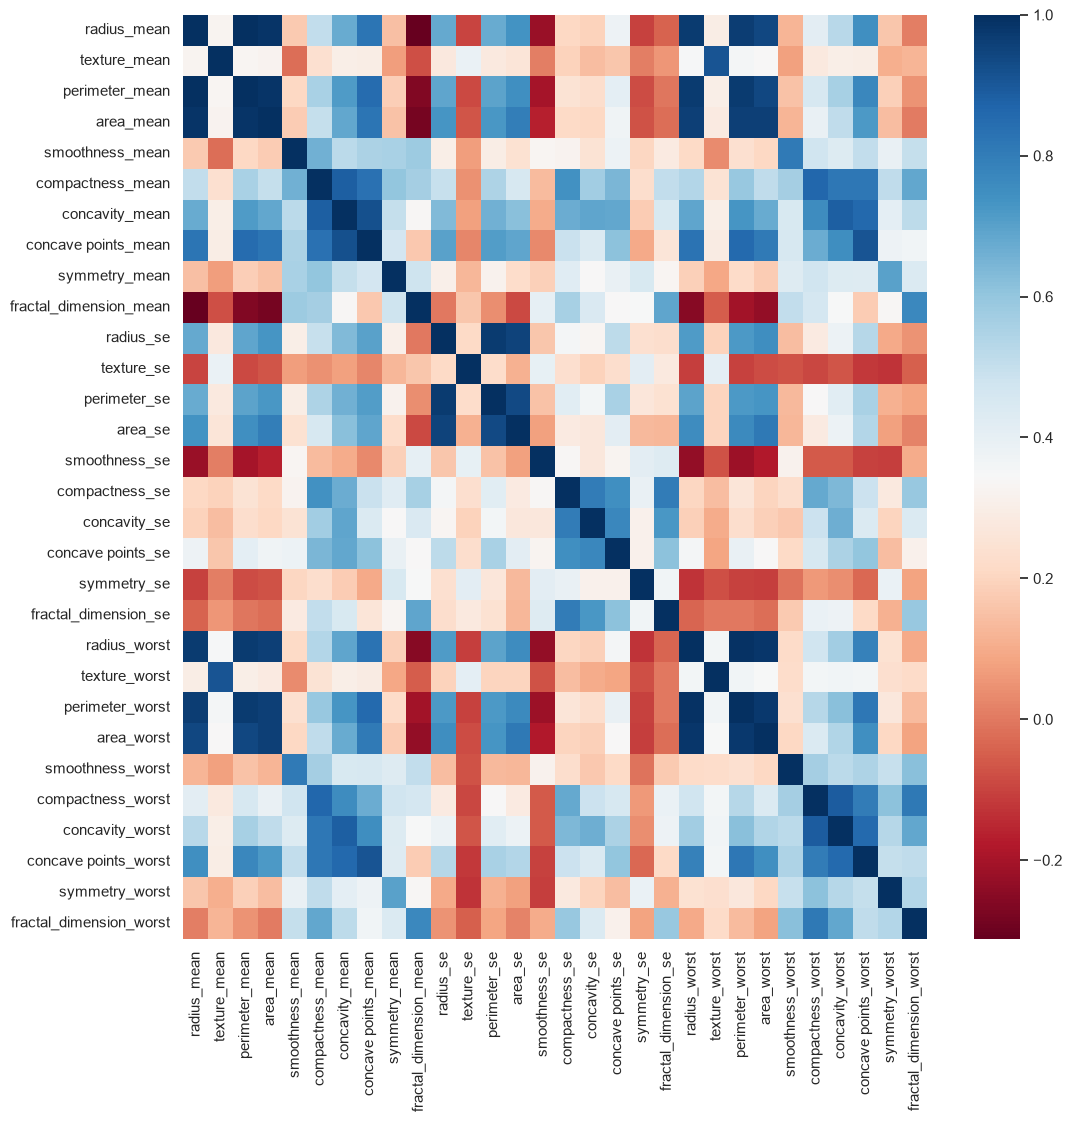

In [55]:
corr = df[num_cols].corr()

sns.set(rc={'figure.figsize': (12, 12)})
sns.heatmap(corr, cmap="RdBu")
plt.show()

Yüksek Korelasyonlu Değişkenlerin Silinmesi

In [60]:
cor_matrix = df[num_cols].corr().abs()  # Sadece sayısal değişkenlerle çalış, mutlak değerleri al

In [61]:
upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col]>0.90) ]
cor_matrix[drop_list]

,perimeter_mean,area_mean,concave points_mean,perimeter_se,area_se,radius_worst,texture_worst,perimeter_worst,area_worst,concave points_worst
radius_mean,0.997855,0.987357,0.822529,0.674172,0.735864,0.969539,0.297008,0.965137,0.941082,0.744214
texture_mean,0.329533,0.321086,0.293464,0.281673,0.259845,0.352573,0.912045,0.358040,0.343546,0.295316
perimeter_mean,1.000000,0.986507,0.850977,0.693135,0.744983,0.969476,0.303038,0.970387,0.941550,0.771241
area_mean,0.986507,1.000000,0.823269,0.726628,0.800086,0.962746,0.287489,0.959120,0.959213,0.722017
smoothness_mean,0.207278,0.177028,0.553695,0.296092,0.246552,0.213120,0.036072,0.238853,0.206718,0.503053
compactness_mean,0.556936,0.498502,0.831135,0.548905,0.455653,0.535315,0.248133,0.590210,0.509604,0.815573
concavity_mean,0.716136,0.685983,0.921391,0.660391,0.617427,0.688236,0.299879,0.729565,0.675987,0.861323
concave points_mean,0.850977,0.823269,1.000000,0.710650,0.690299,0.830318,0.292752,0.855923,0.809630,0.910155
symmetry_mean,0.183027,0.151293,0.462497,0.313893,0.223970,0.185728,0.090651,0.219169,0.177193,0.430297
fractal_dimension_mean,0.261477,0.283110,0.166917,0.039830,0.090170,0.253691,0.051269,0.205151,0.231854,0.175325


In [62]:
df.drop(drop_list, axis=1)


,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,concavity_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,smoothness_worst,compactness_worst,concavity_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,0.11840,0.27760,0.30010,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,0.16220,0.66560,0.7119,0.4601,0.11890
1,M,20.57,17.77,0.08474,0.07864,0.08690,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,0.12380,0.18660,0.2416,0.2750,0.08902
2,M,19.69,21.25,0.10960,0.15990,0.19740,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,0.14440,0.42450,0.4504,0.3613,0.08758
3,M,11.42,20.38,0.14250,0.28390,0.24140,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,0.20980,0.86630,0.6869,0.6638,0.17300
4,M,20.29,14.34,0.10030,0.13280,0.19800,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,0.13740,0.20500,0.4000,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,0.11100,0.11590,0.24390,0.1726,0.05623,1.1760,1.2560,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,0.14100,0.21130,0.4107,0.2060,0.07115
565,M,20.13,28.25,0.09780,0.10340,0.14400,0.1752,0.05533,0.7655,2.4630,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,0.11660,0.19220,0.3215,0.2572,0.06637
566,M,16.60,28.08,0.08455,0.10230,0.09251,0.1590,0.05648,0.4564,1.0750,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,0.11390,0.30940,0.3403,0.2218,0.07820
567,M,20.60,29.33,0.11780,0.27700,0.35140,0.2397,0.07016,0.7260,1.5950,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,0.16500,0.86810,0.9387,0.4087,0.12400


In [64]:
def high_correlated_cols(dataframe, plot=False, corr_th=0.90):
    """
    Bu fonksiyon, bir veri çerçevesindeki (dataframe) çok yüksek korelasyona sahip değişkenlerin isimlerini tespit etmek için kullanılır.

    Parametreler:
    ------------
    dataframe : pandas.DataFrame
        Korelasyon analizi yapılacak veri çerçevesi. Sadece sayısal değişkenlerin alınması tavsiye edilir.
    plot : bool, default=False
        Eğer True seçilirse, korelasyon matrisi bir ısı haritası olarak görselleştirilir.
    corr_th : float, default=0.90
        Korelasyon eşik değeri. Bu değerden yüksek korelasyon gösteren değişken çiftlerinden biri atılacak şekilde döndürülür.

    Returns
    -------
    drop_list : list
        Yüksek korelasyona sahip sütun isimleri.
    """

    # Sadece sayısal sütunlarla çalış
    num_cols = [col for col in dataframe.columns if dataframe[col].dtype in [int, float]]
    corr = dataframe[num_cols].corr()  # Hata burada; tüm df yerine yalnızca sayısal sütunlarla çalışmalı
    cor_matrix = corr.abs()
    upper_triangle_matrix = cor_matrix.where(np.triu(np.ones(cor_matrix.shape), k=1).astype(bool))
    drop_list = [col for col in upper_triangle_matrix.columns if any(upper_triangle_matrix[col] > corr_th)]
    if plot:
        sns.set(rc={'figure.figsize': (15, 15)})
        sns.heatmap(corr, cmap="RdBu")
        plt.show()
    return drop_list

high_correlated_cols(df)

['perimeter_mean',
 'area_mean',
 'concave points_mean',
 'perimeter_se',
 'area_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'concave points_worst']

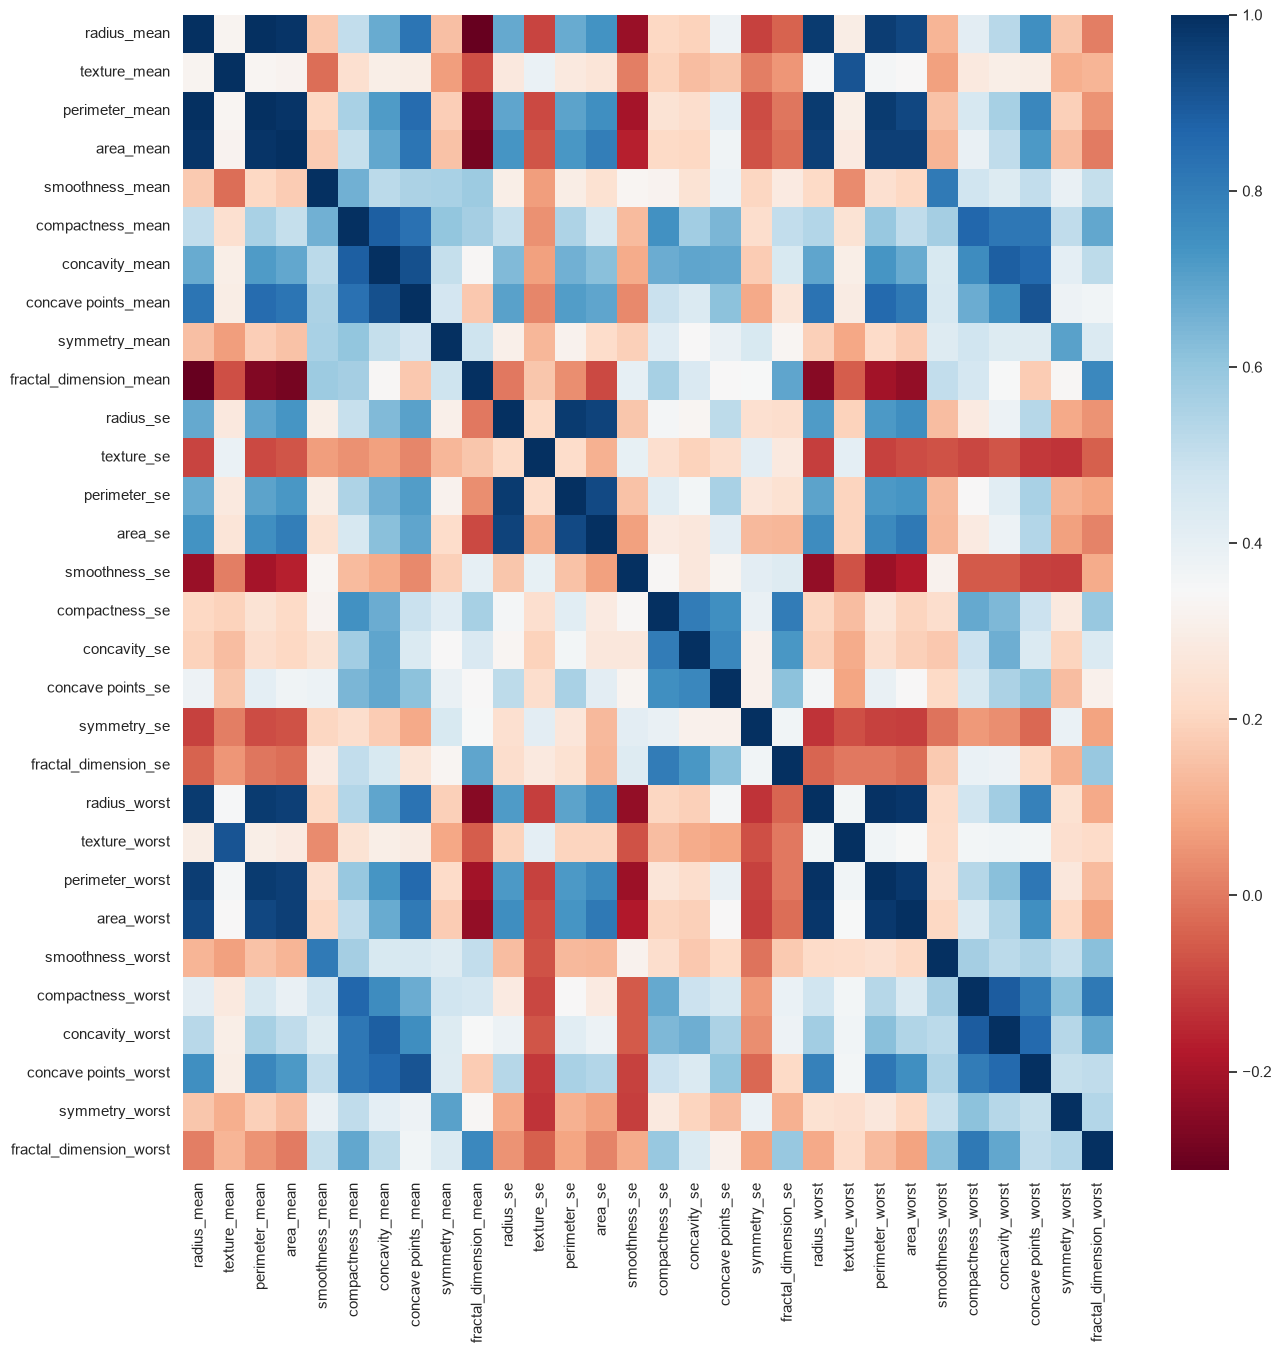

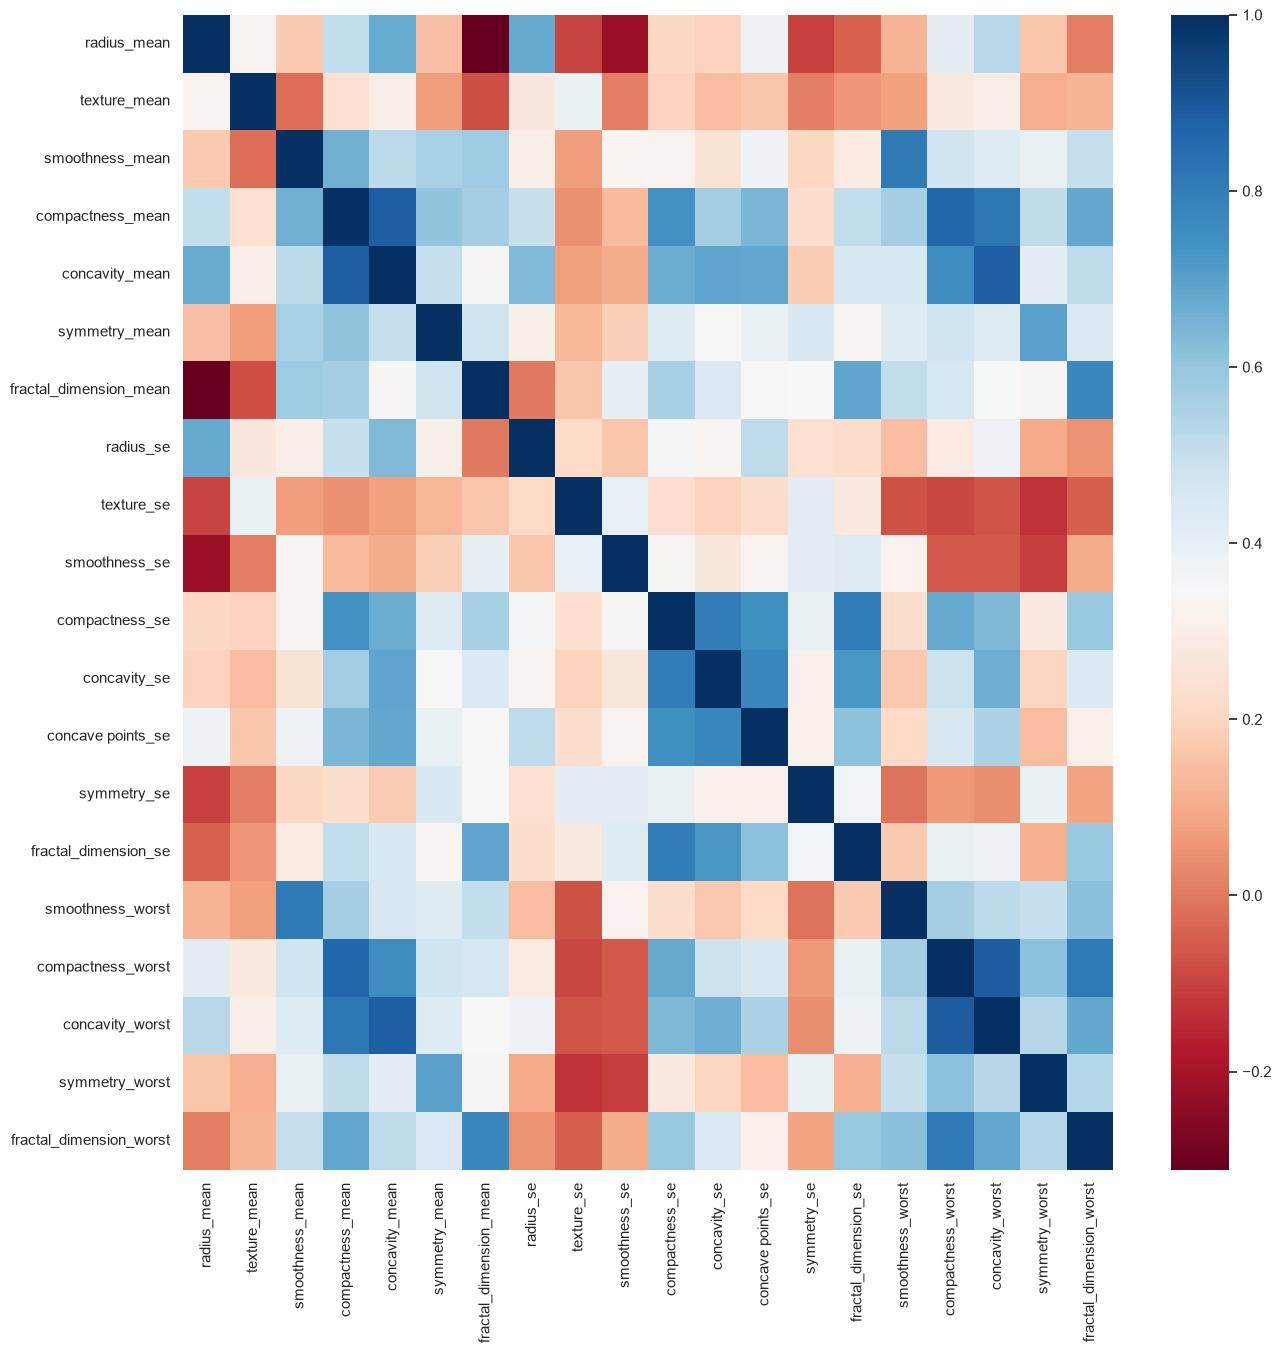

[]

In [65]:
drop_list = high_correlated_cols(df, plot=True)
df.drop(drop_list, axis=1)
high_correlated_cols(df.drop(drop_list, axis=1), plot=True)

In [ ]:
# Yaklaşık 600 mb'lık 300'den fazla değişkenin olduğu bir veri setinde deneyelim.
# https://www.kaggle.com/c/ieee-fraud-detection/data?select=train_transaction.csv

df = pd.read_csv("datasets/fraud_train_transaction.csv")
len(df.columns)
df.head()

drop_list = high_correlated_cols(df, plot=True)

len(df.drop(drop_list, axis=1).columns)
